In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [46]:
df = pd.read_csv("data.csv")

In [47]:
df.sample()


,feature1,feature2,feature3,target
56,-0.712993,0.625245,-1.023785,-95.106074


In [48]:
x = df.iloc[:,0:3]
y = df.iloc[:,-1]

In [49]:
x_train,x_test ,y_train ,y_test = train_test_split(x,y , test_size=0.2 ,random_state=2)

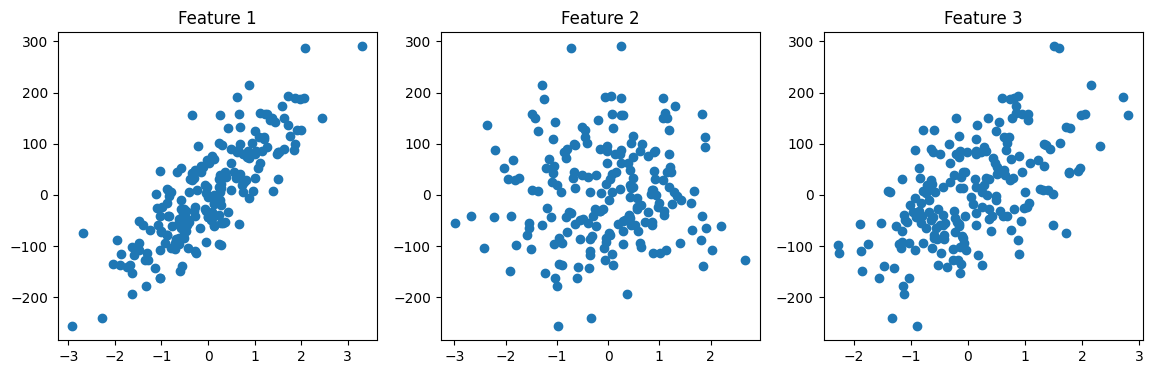

In [50]:
plt.figure(figsize=(14,4))
plt.subplot(131)
plt.scatter(df['feature1'] , df['target'])
plt.title("Feature 1")

plt.subplot(132)
plt.scatter(df['feature2'] , df['target'])
plt.title("Feature 2")

plt.subplot(133)
plt.scatter(df['feature3'] , df['target'])
plt.title("Feature 3")

plt.show()

## **Detecting Multicolinearity**

- If its value is colse to 1 then no multicolinearity if value is 5 or more then 5 then multicollinearity is  present

In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [52]:
vif = []

for i in range(x_train.shape[1]):
    vif.append(variance_inflation_factor(x_train,i))

In [53]:
pd.DataFrame({"vif" : vif} , index=df.columns[0:3]).T  # Values Mostly Colse to 1 or few greater to 1  
# Indicating No Multicolinearity here

,feature1,feature2,feature3
vif,1.003482,1.005274,1.006564


<Axes: >

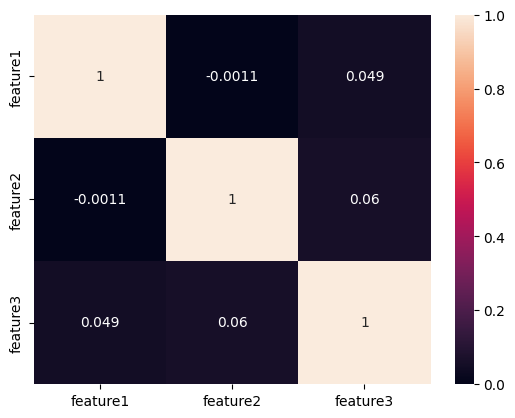

In [54]:
# Another Tecnique
sns.heatmap(df.iloc[:,0:3].corr() , annot=True)  # See Realtion ship below ny diagnol  (feature 3 with feaature 1 | feature2 with feature1 | feature 1 with feature 3)

# **Normal Residuals**

In [55]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
y_pred = lr.predict(x_test)

In [57]:
residuals = y_test - y_pred

<Axes: xlabel='target', ylabel='Density'>

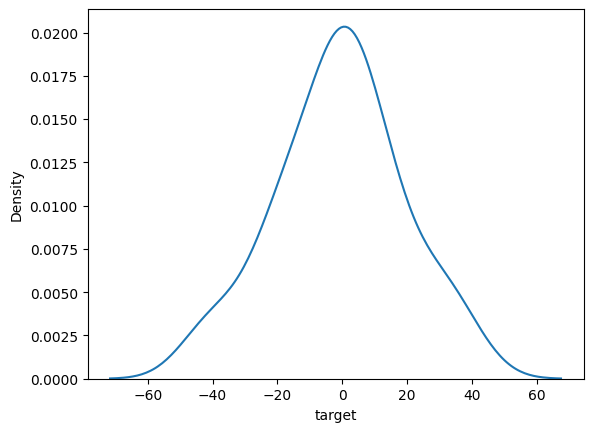

In [58]:
sns.kdeplot(residuals)

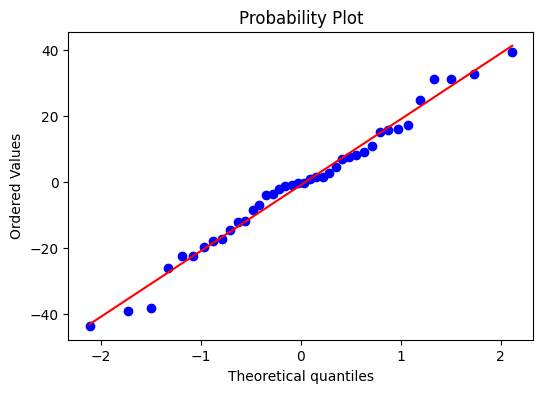

In [59]:
import scipy as sp

fg , ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residuals , plot =ax , fit=True)
plt.show()

# **Homoscedasticity**

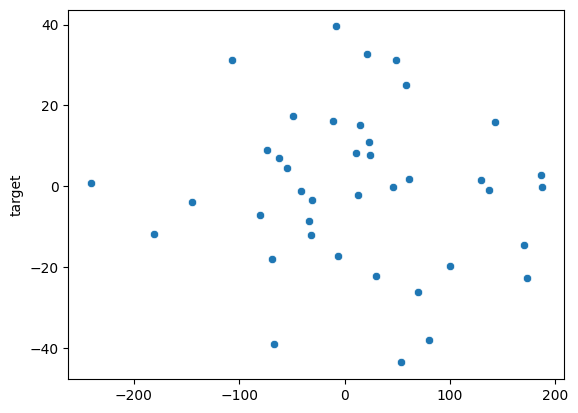

In [60]:
sns.scatterplot(x = y_pred , y =  residuals)  # Uniform acceptable 
plt.show()

# **Autocorrelation of Error**

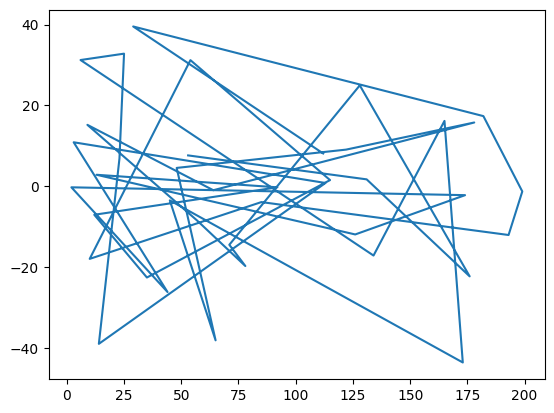

In [61]:
plt.plot(residuals)
plt.show()